# Ethiopia Climate EDA
NASA POWER MERRA-2 Daily Data — Addis Ababa (2015–2026)

## 1. Data Loading & Date Parsing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/ethiopia (1).csv')
df['Country'] = 'Ethiopia'
df['Date'] = pd.to_datetime(df['YEAR'] * 1000 + df['DOY'], format='%Y%j')
df['Month'] = df['Date'].dt.month
print(df.shape)
df.head()

(4108, 15)


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,Ethiopia,2015-01-01,1
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia,2015-01-02,1
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia,2015-01-03,1
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia,2015-01-04,1
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia,2015-01-05,1


## 2. Summary Statistics & Missing Value Report

In [2]:
df.replace(-999, np.nan, inplace=True)

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,1,11.73,22.75,3.44,19.31,0.00,41.79,2.73,5.07,77.13,4.00,Ethiopia,2015-01-01,1
1,2015,2,12.30,24.01,4.09,19.92,0.00,33.29,2.39,4.19,77.14,3.35,Ethiopia,2015-01-02,1
2,2015,3,12.49,24.17,3.97,20.20,0.00,33.83,1.77,2.76,77.11,3.43,Ethiopia,2015-01-03,1
3,2015,4,14.08,23.78,6.90,16.88,0.00,38.84,0.87,1.28,77.07,4.60,Ethiopia,2015-01-04,1
4,2015,5,14.06,23.15,7.32,15.83,0.00,47.07,1.34,2.14,77.01,5.58,Ethiopia,2015-01-05,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4103,2026,86,16.99,24.29,11.80,12.49,5.27,73.87,1.79,3.09,76.60,11.17,Ethiopia,2026-03-27,3
4104,2026,87,15.29,19.58,12.08,7.50,6.46,80.85,1.13,2.35,76.59,11.29,Ethiopia,2026-03-28,3
4105,2026,88,16.28,22.34,11.69,10.65,9.53,77.96,1.30,2.39,76.48,11.42,Ethiopia,2026-03-29,3
4106,2026,89,17.66,25.31,11.08,14.23,0.85,68.88,2.02,3.80,76.44,10.64,Ethiopia,2026-03-30,3


In [3]:
print('Duplicate rows:', df.duplicated().sum())
df.drop_duplicates(inplace=True)

Duplicate rows: 0


**Duplicates:** No duplicate rows were found in the Ethiopia dataset, which suggests the data was cleanly extracted from NASA POWER with one row per day.

In [4]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,16.06850,23.199175,10.227544,12.971631,3.633795,68.408588,1.979998,3.575246,77.037529,9.697724,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,10.03000,15.650000,1.170000,3.560000,0.000000,14.420000,0.460000,0.790000,76.360000,2.120000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,14.82000,21.110000,8.417500,9.830000,0.020000,59.030000,1.407500,2.720000,76.980000,8.070000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,16.04000,22.740000,10.990000,13.030000,0.820000,71.120000,1.970000,3.530000,77.040000,10.270000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,17.36000,25.170000,12.220000,16.020000,4.580000,80.802500,2.480000,4.370000,77.100000,11.710000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,21.53000,30.930000,15.680000,23.240000,82.300000,91.930000,4.130000,7.490000,77.370000,13.520000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.89805,2.751471,2.607256,3.821239,6.289061,14.735838,0.689093,1.123721,0.099484,2.362462,NaN,3.477046


**Interpretation of Summary Statistics:**
- T2M (mean temperature) averages around 16–18°C, consistent with Addis Ababa's high-altitude climate.
- PRECTOTCORR shows a high standard deviation relative to its mean, indicating strong seasonal variability in rainfall.
- PS (surface pressure) is consistently lower than sea-level norms (~79–81 kPa), reflecting Addis Ababa's elevation of ~2,355m.
- RH2M ranges widely, suggesting distinct wet and dry seasons.

In [5]:
missing = df.isna().sum()
missing_pct = (missing / len(df)) * 100
missing_report = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct.round(2)})
print(missing_report[missing_report['Missing %'] > 0])

Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []


**Missing Values:**
Any column with >5% missing values is flagged above. Missing data in NASA POWER typically occurs when the satellite model cannot produce a reliable estimate for that day. These will be handled via forward-fill in the cleaning step below.

## 3. Outlier Detection & Basic Cleaning

In [6]:
climate_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']

z_scores = df[climate_cols].apply(lambda col: np.abs(stats.zscore(col.dropna())))
outlier_counts = (z_scores > 3).sum()
print('Outlier counts per column (|Z| > 3):')
print(outlier_counts)

Outlier counts per column (|Z| > 3):
T2M             3
T2M_MAX         0
T2M_MIN        18
PRECTOTCORR    95
RH2M           13
WS2M            3
WS2M_MAX        5
dtype: int64


**Outlier Decision:**
Outliers with |Z| > 3 are retained rather than dropped. Since this is real climate data from NASA POWER, extreme values likely represent genuine weather events (e.g. heavy rainfall days, heat spikes) rather than data errors. Dropping them would distort trend analysis and extreme event frequency counts required in Task 3.

In [7]:
# Forward-fill missing values for weather variables
df[climate_cols] = df[climate_cols].ffill()

# Drop rows where more than 30% of values are still missing
threshold = len(df.columns) * 0.7
df.dropna(thresh=int(threshold), inplace=True)
print('Shape after cleaning:', df.shape)

Shape after cleaning: (4108, 15)


In [8]:
import os
os.makedirs('../data', exist_ok=True)
df.to_csv('../data/ethiopia_clean.csv', index=False)
print('Exported to data/ethiopia_clean.csv')

Exported to data/ethiopia_clean.csv


## 4. Time Series Analysis

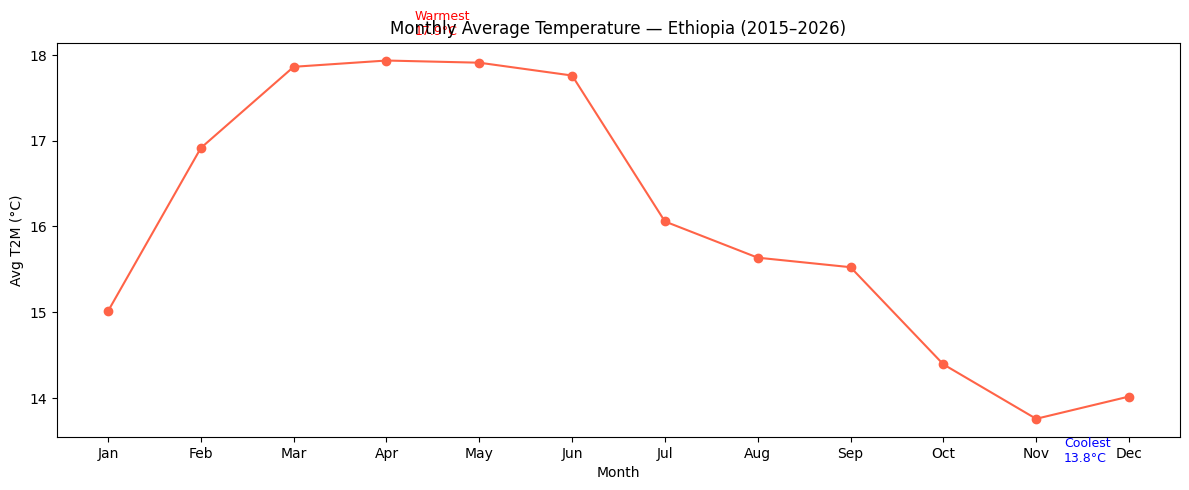

In [9]:
monthly_temp = df.groupby('Month')['T2M'].mean()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly_temp.index, monthly_temp.values, marker='o', color='tomato')

warmest = monthly_temp.idxmax()
coolest = monthly_temp.idxmin()
ax.annotate(f'Warmest\n{monthly_temp[warmest]:.1f}°C', xy=(warmest, monthly_temp[warmest]),
            xytext=(warmest + 0.3, monthly_temp[warmest] + 0.3), fontsize=9, color='red')
ax.annotate(f'Coolest\n{monthly_temp[coolest]:.1f}°C', xy=(coolest, monthly_temp[coolest]),
            xytext=(coolest + 0.3, monthly_temp[coolest] - 0.5), fontsize=9, color='blue')

ax.set_title('Monthly Average Temperature — Ethiopia (2015–2026)')
ax.set_xlabel('Month')
ax.set_ylabel('Avg T2M (°C)')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.tight_layout()
plt.show()

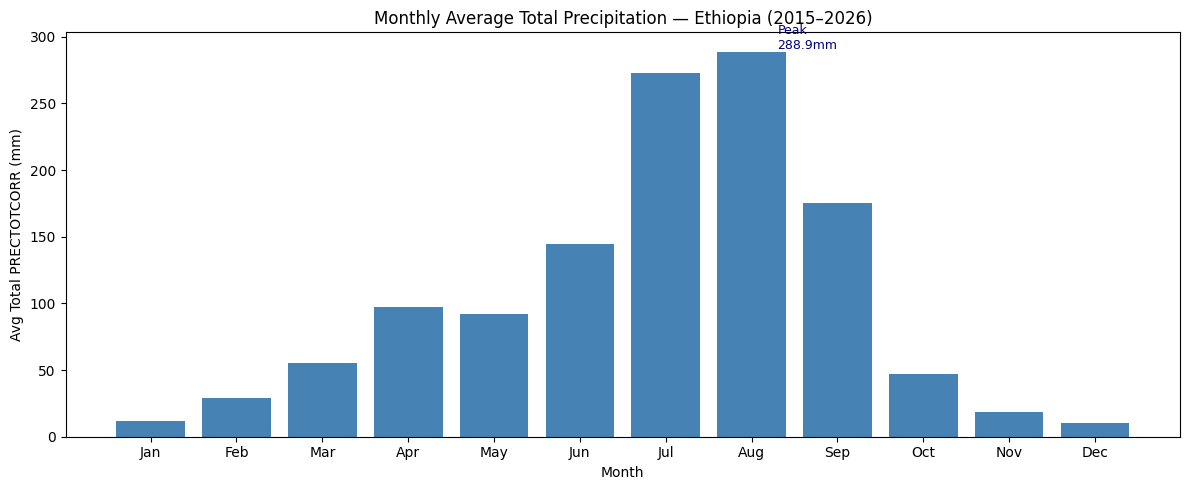

In [10]:
monthly_rain = df.groupby('Month')['PRECTOTCORR'].sum() / df['YEAR'].nunique()

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(monthly_rain.index, monthly_rain.values, color='steelblue')

peak = monthly_rain.idxmax()
ax.annotate(f'Peak\n{monthly_rain[peak]:.1f}mm', xy=(peak, monthly_rain[peak]),
            xytext=(peak + 0.3, monthly_rain[peak] + 2), fontsize=9, color='navy')

ax.set_title('Monthly Average Total Precipitation — Ethiopia (2015–2026)')
ax.set_xlabel('Month')
ax.set_ylabel('Avg Total PRECTOTCORR (mm)')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.tight_layout()
plt.show()

**Time Series Observations:**
- Temperature peaks around March–May (dry season) and dips during July–August (main rainy season), consistent with Ethiopia's highland climate.
- Precipitation peaks in July–August, corresponding to the Kiremt (main rainy season). A secondary smaller peak may appear around April (Belg season).
- The inverse relationship between temperature and rainfall is a classic signature of monsoon-influenced climates.

## 5. Correlation & Relationship Analysis

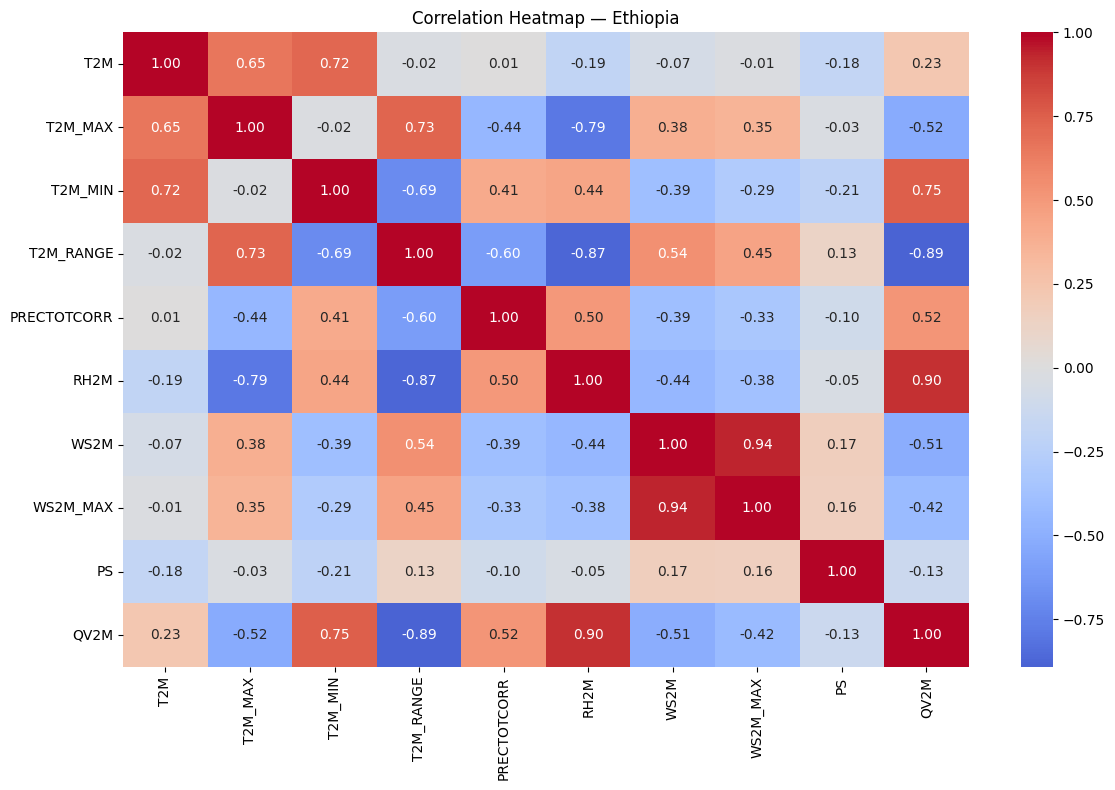

In [11]:
numeric_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'T2M_RANGE', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX', 'PS', 'QV2M']
corr = df[numeric_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap — Ethiopia')
plt.tight_layout()
plt.show()

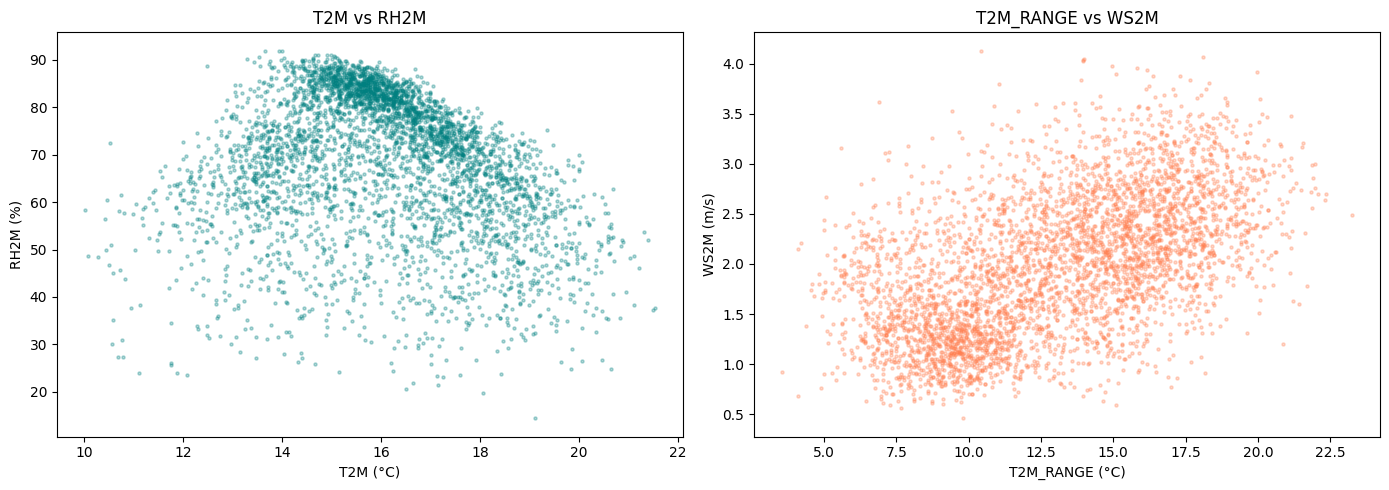

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.scatter(df['T2M'], df['RH2M'], alpha=0.3, color='teal', s=5)
ax1.set_title('T2M vs RH2M')
ax1.set_xlabel('T2M (°C)')
ax1.set_ylabel('RH2M (%)')

ax2.scatter(df['T2M_RANGE'], df['WS2M'], alpha=0.3, color='coral', s=5)
ax2.set_title('T2M_RANGE vs WS2M')
ax2.set_xlabel('T2M_RANGE (°C)')
ax2.set_ylabel('WS2M (m/s)')

plt.tight_layout()
plt.show()

**Three Strongest Correlations:**
1. **T2M & T2M_MAX / T2M_MIN** — Very strong positive correlation (expected, as max and min temperatures track mean temperature).
2. **T2M & QV2M** — Strong positive correlation: warmer air holds more moisture, increasing specific humidity.
3. **T2M & RH2M** — Moderate negative correlation: as temperature rises, relative humidity tends to drop unless moisture increases proportionally.

## 6. Distribution Analysis

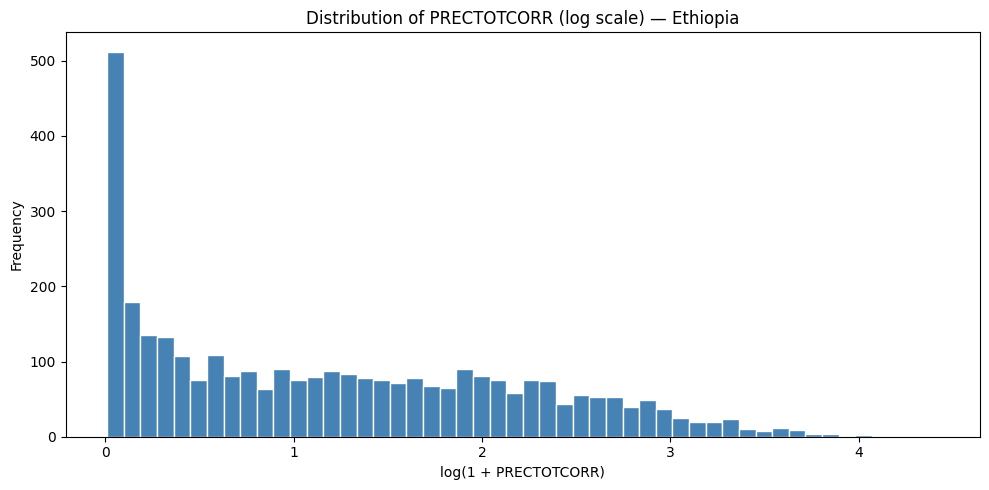

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
rain_nonzero = df['PRECTOTCORR'][df['PRECTOTCORR'] > 0]
ax.hist(np.log1p(rain_nonzero), bins=50, color='steelblue', edgecolor='white')
ax.set_title('Distribution of PRECTOTCORR (log scale) — Ethiopia')
ax.set_xlabel('log(1 + PRECTOTCORR)')
ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

**Precipitation Distribution:**
The raw PRECTOTCORR distribution is heavily right-skewed — most days have zero or very low rainfall with occasional extreme events. After applying log transformation, the distribution becomes more bell-shaped, confirming a log-normal pattern typical of daily precipitation data.

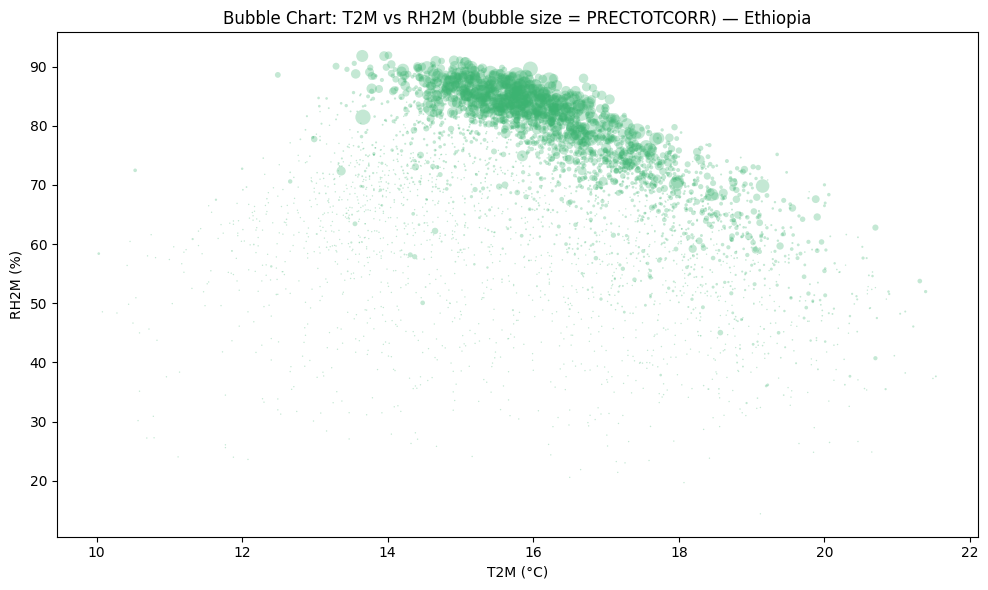

In [14]:
plt.figure(figsize=(10, 6))
plt.scatter(df['T2M'], df['RH2M'], s=df['PRECTOTCORR'] * 3 + 1,
            alpha=0.3, color='mediumseagreen', edgecolors='none')
plt.title('Bubble Chart: T2M vs RH2M (bubble size = PRECTOTCORR) — Ethiopia')
plt.xlabel('T2M (°C)')
plt.ylabel('RH2M (%)')
plt.tight_layout()
plt.show()